<a href="https://www.kaggle.com/code/sonawanelalitsunil/top-1k-most-sub-ytchannels-in-germany-lr-ml?scriptVersionId=224536461" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/1000-most-subscribed-youtube-channels-in-germany/top-1000-most-subscribed-youtube-channels-in-germany.csv


## Title:
## "Top 1000 Most Subscribed YouTube Channels in Germany"

## Detailed Description:

This dataset provides a comprehensive list of the 1000 most subscribed YouTube channels in Germany, offering insights into the country's digital content landscape. It includes various metadata points for each channel, such as:

Channel Name – The official name of the YouTube channel.

Subscriber Count – The number of subscribers, reflecting the channel's reach.

Category/Genre – The type of content produced, such as Gaming, Education, Entertainment, Music, Tech, etc.

Total Views – The cumulative number of views on all uploaded videos.

Total Videos – The number of videos published by the channel.

Creation Date – The date when the channel was created.

Country – Confirming that the channel is based in Germany.

Language – The primary language used in the channel’s content.

Engagement Metrics (Optional) – Average likes, comments, and shares per video.

This dataset is valuable for researchers, marketers, and content creators looking to analyze trends in the German YouTube ecosystem. It can help identify popular content genres, study audience preferences, and track the rise of new influencers.

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Import dataset

In [3]:
df = pd.read_csv("/kaggle/input/1000-most-subscribed-youtube-channels-in-germany/top-1000-most-subscribed-youtube-channels-in-germany.csv")

In [4]:
df.head()

,rank,Youtuber,subscribers,video views,video count,category,started
0,1,Tsuriki Show,"34,100,000","42,490,526,838","4,739",Entertainment,2019
1,2,Kidibli (Kinder Spielzeug Kanal),"29,600,000","15,673,364,837","1,236",Entertainment,2015
2,3,Kurzgesagt – In a Nutshell,"23,600,000","3,145,706,013",271,Education,2013
3,4,boxtoxtv,"23,500,000","18,303,986,629","1,559",Comedy,2022
4,5,HaerteTest,"19,500,000","3,420,864,412","1,712",Science & Technology,2011


In [5]:
df.tail()

,rank,Youtuber,subscribers,video views,video count,category,started
995,996,Goaltinho,"556,000","177,177,157",654,Sports,2022
996,997,byStegi,"556,000","57,192,052",325,Gaming,2012
997,998,Jasmin Gnu,"556,000","105,664,179",395,People & Blogs,2019
998,999,Beat-Club,"555,000","376,768,424","1,651",https://us.youtubers.me/germany/all/top-1000-m...,2009
999,1000,Mark Kvas,"555,000","67,134,384",35,Gaming,2019


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   rank         1000 non-null   int64 
 1   Youtuber     1000 non-null   object
 2   subscribers  1000 non-null   object
 3   video views  1000 non-null   object
 4   video count  1000 non-null   object
 5   category     1000 non-null   object
 6   started      1000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 54.8+ KB


In [7]:
df.describe()

,rank,started
count,1000.000000,1000.000000
mean,500.500000,2014.745000
std,288.819436,4.243581
min,1.000000,2005.000000
25%,250.750000,2012.000000
50%,500.500000,2015.000000
75%,750.250000,2018.000000
max,1000.000000,2024.000000


In [8]:
df.isnull().sum()

rank           0
Youtuber       0
subscribers    0
video views    0
video count    0
category       0
started        0
dtype: int64

In [9]:
df.isnull().sum().sum()

0

In [10]:
df.corr

<bound method DataFrame.corr of      rank                          Youtuber subscribers     video views  \
0       1                      Tsuriki Show  34,100,000  42,490,526,838   
1       2  Kidibli (Kinder Spielzeug Kanal)  29,600,000  15,673,364,837   
2       3        Kurzgesagt – In a Nutshell  23,600,000   3,145,706,013   
3       4                          boxtoxtv  23,500,000  18,303,986,629   
4       5                        HaerteTest  19,500,000   3,420,864,412   
..    ...                               ...         ...             ...   
995   996                         Goaltinho     556,000     177,177,157   
996   997                           byStegi     556,000      57,192,052   
997   998                        Jasmin Gnu     556,000     105,664,179   
998   999                         Beat-Club     555,000     376,768,424   
999  1000                         Mark Kvas     555,000      67,134,384   

    video count                                           category 

In [11]:
df.shape

(1000, 7)

In [12]:
df.columns

Index(['rank', 'Youtuber', 'subscribers', 'video views', 'video count',
       'category', 'started'],
      dtype='object')

## Data visulizations

In [13]:
def convert_count(x):
    """Convert string counts with potential suffixes like 'K' or 'M' into a float."""
    try:
        x = x.replace(',', '').strip()
        if x[-1] in ['K', 'M']:
            if x[-1] == 'K':
                return float(x[:-1]) * 1e3
            elif x[-1] == 'M':
                return float(x[:-1]) * 1e6
        return float(x)
    except Exception as e:
        # Logging the error and returning NaN so that we can identify issues later
        print(f"Error converting {x}: {e}")
        return np.nan

# Create copies of the columns after cleaning
df['subscribers_clean'] = df['subscribers'].astype(str).apply(convert_count)
df['video_views_clean'] = df['video views'].astype(str).apply(convert_count)
df['video_count_clean'] = df['video count'].astype(str).apply(convert_count)

# Convert 'started' column to datetime by treating it as a year
df['started_dt'] = pd.to_datetime(df['started'], format='%Y', errors='coerce')

# Optionally drop or investigate rows with conversion errors
print('Data cleaning complete. Summary:')
print(df[['subscribers_clean', 'video_views_clean', 'video_count_clean', 'started_dt']].describe())

Data cleaning complete. Summary:
       subscribers_clean  video_views_clean  video_count_clean  \
count       1.000000e+03       1.000000e+03        1000.000000   
mean        1.650848e+06       7.776687e+08        1855.945000   
min         5.550000e+05       0.000000e+00           0.000000   
25%         7.117500e+05       1.787142e+08         350.750000   
50%         1.035000e+06       3.782629e+08         777.500000   
75%         1.692500e+06       7.852321e+08        1637.500000   
max         3.410000e+07       4.249053e+10      102445.000000   
std         2.382896e+06       1.873448e+09        5389.928703   

                started_dt  
count                 1000  
mean   2014-09-29 23:09:36  
min    2005-01-01 00:00:00  
25%    2012-01-01 00:00:00  
50%    2015-01-01 00:00:00  
75%    2018-01-01 00:00:00  
max    2024-01-01 00:00:00  
std                    NaN  


In [14]:
print(df.columns)

Index(['rank', 'Youtuber', 'subscribers', 'video views', 'video count',
       'category', 'started', 'subscribers_clean', 'video_views_clean',
       'video_count_clean', 'started_dt'],
      dtype='object')


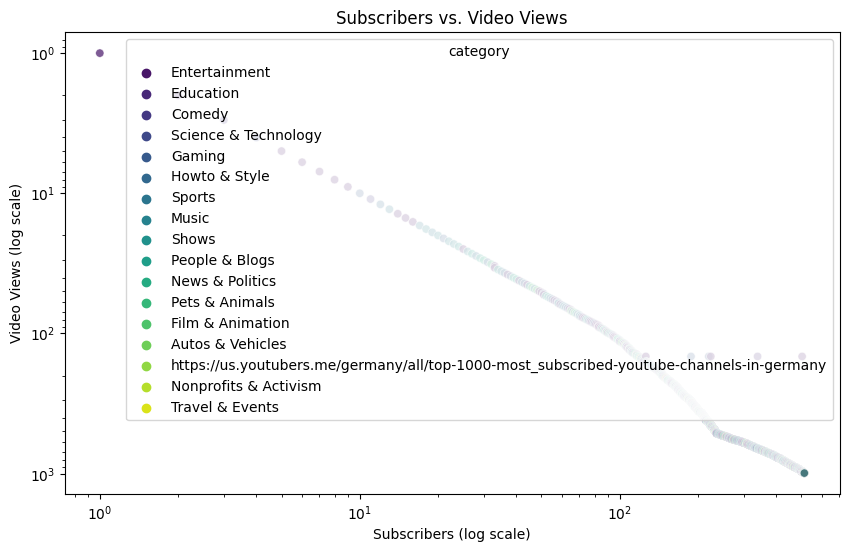

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['subscribers'], y=df['video views'], hue=df['category'], palette='viridis', alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Subscribers (log scale)")
plt.ylabel("Video Views (log scale)")
plt.title("Subscribers vs. Video Views")
plt.show()

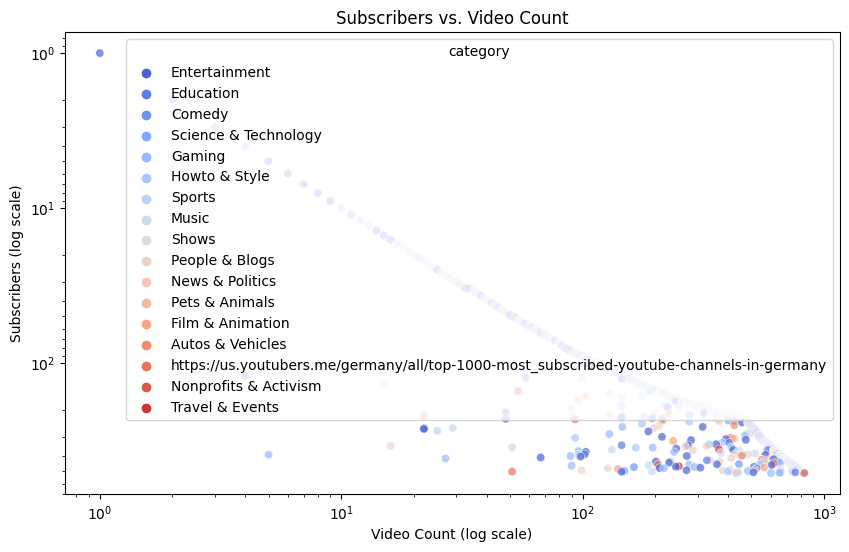

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['video count'], y=df['subscribers'], hue=df['category'], palette='coolwarm', alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Video Count (log scale)")
plt.ylabel("Subscribers (log scale)")
plt.title("Subscribers vs. Video Count")
plt.show()

In [17]:
numeric_df = df[['rank', 'subscribers_clean', 'video_views_clean', 'video_count_clean']].dropna()

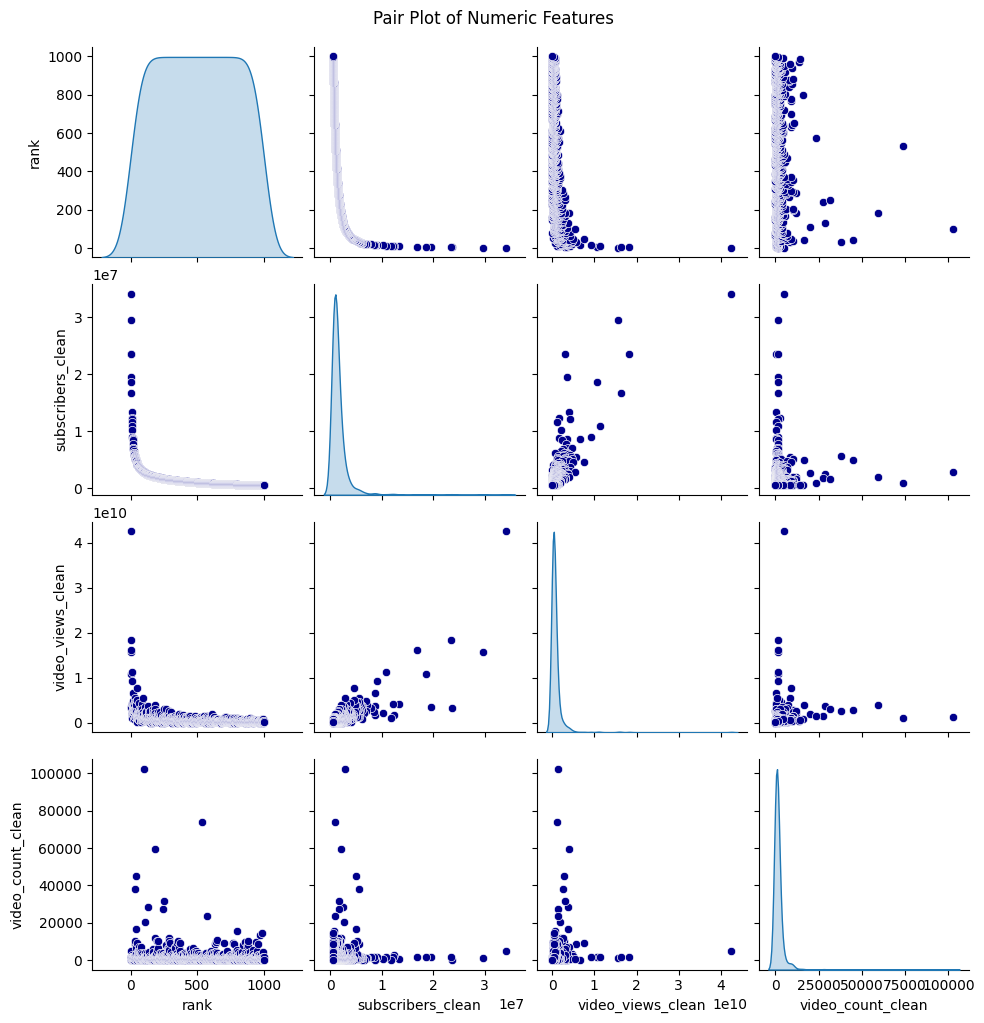

In [18]:
# Set a custom color palette
custom_palette = sns.color_palette(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"])

sns.pairplot(numeric_df, diag_kind="kde", markers=["o"], plot_kws={"color": "darkblue"})
plt.suptitle("Pair Plot of Numeric Features", y=1.02)
plt.show()

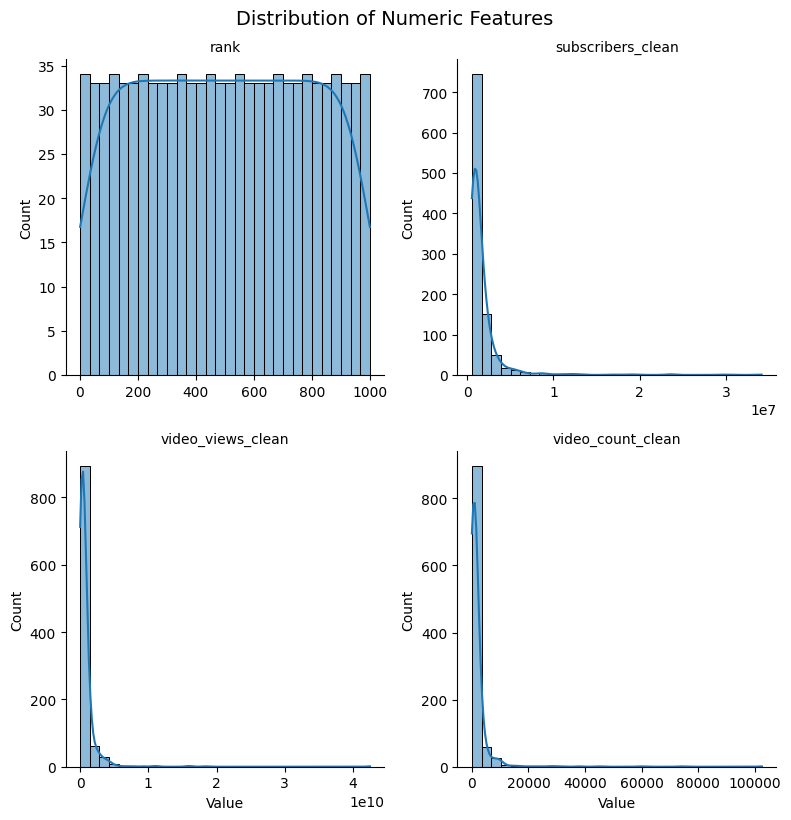

In [19]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
df_long = numeric_df.melt(value_vars=['rank', 'subscribers_clean', 'video_views_clean', 'video_count_clean'], 
                           var_name="Feature", value_name="Value")
g = sns.FacetGrid(df_long, col="Feature", col_wrap=2, height=4, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x="Value", bins=30, kde=True, color=colors.pop(0))
g.set_titles("{col_name}")  # Set subplot titles
plt.suptitle("Distribution of Numeric Features", y=1.02, fontsize=14)
plt.show()

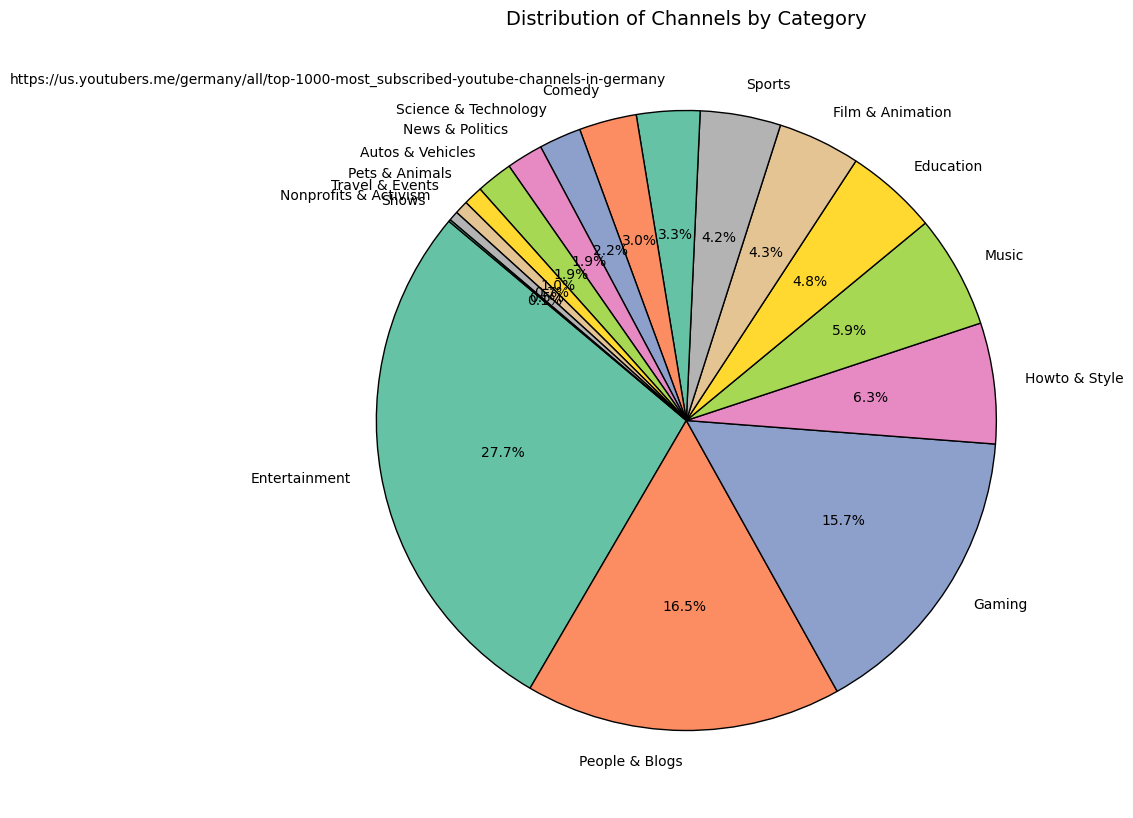

In [20]:
colors = sns.color_palette("Set2", len(df['category'].unique()))  # Generate unique colors
plt.figure(figsize=(10, 18))
plt.pie(df['category'].value_counts(), 
        labels=df['category'].value_counts().index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        wedgeprops={'edgecolor': 'black'})  # Adding border for clarity
plt.title("Distribution of Channels by Category", fontsize=14)
plt.show()

## EDA

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [22]:
# Drop missing values and create a copy of the dataset
df_model = df.dropna(subset=['subscribers_clean', 'video_views_clean', 'video_count_clean', 'started_dt']).copy()

In [23]:
df_model['start_year'] = df_model['started_dt'].dt.year

In [24]:
# Features and target variable
X = df_model[['video_views_clean', 'video_count_clean', 'start_year']]
y = df_model['subscribers_clean']

In [25]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Define models to test
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor": SVR(kernel='rbf'),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

In [27]:
# Store results
results = {}

In [28]:
# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    results[name] = {'R2 Score': r2, 'MSE': mse}
    
    print(f"{name} - R2 Score: {r2:.4f}, MSE: {mse:.2f}")

Linear Regression - R2 Score: 0.3042, MSE: 1109910468662.97
Random Forest - R2 Score: 0.0434, MSE: 1526062516439.32
Gradient Boosting - R2 Score: 0.0849, MSE: 1459777275852.90
Support Vector Regressor - R2 Score: -0.0977, MSE: 1751113262807.44
XGBoost - R2 Score: -0.0217, MSE: 1629858017873.87


In [29]:
# Convert results to a DataFrame
results_df = pd.DataFrame(results).T

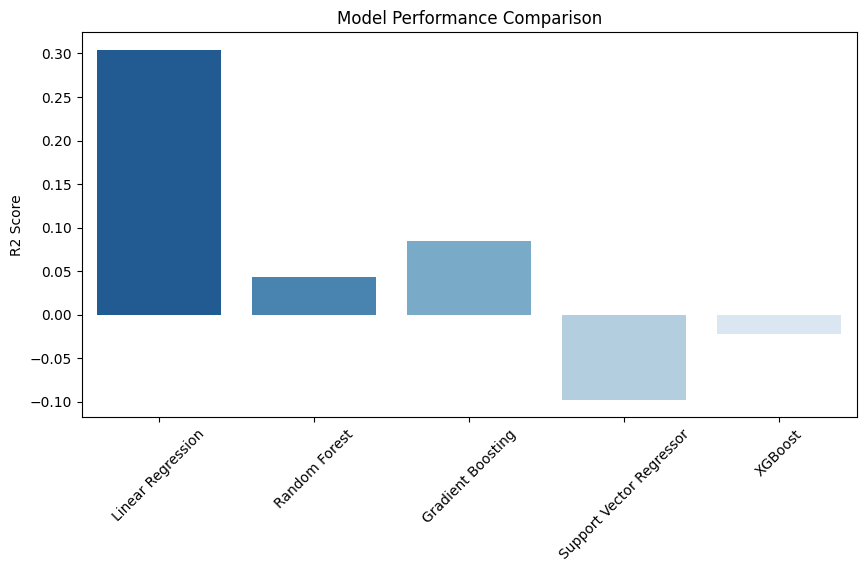


Best Model: Linear Regression with R2 Score of 0.3042


In [30]:
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df['R2 Score'], palette="Blues_r")
plt.ylabel('R2 Score')
plt.xticks(rotation=45)
plt.title('Model Performance Comparison')
plt.show()

# Print the best model
best_model = results_df['R2 Score'].idxmax()
print(f"\nBest Model: {best_model} with R2 Score of {results_df.loc[best_model, 'R2 Score']:.4f}")

# Thank you!!!!...Pls upvote..